## 3D Vector Field Visualization in Porous Media in PyVista

Authors: Masa Prodanovic and Bernard Chang

Updated: July 2022

All rights reserved.    

Please see plots3d_surface_visualization_porous_media_pyvista.ipynb file for installation instructions.

We here exemplify visualization of a velocity field, in particular, experimentally measured velocity field available on Digital Rocks Portal. For this purpose a smaller subset has been resized and placed in the data subfolder.

In [1]:
# imports
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

## Load data and plot a cross section

In [3]:
# load velocity data
# [0,99]x[0,99]x[0,99] subset of https://www.digitalrocksportal.org/projects/175
# experimentally measured velocity field in a packing of spheres
vx = np.load('../data/3d_spherepack_project175/vx_rsz_100.npy')
vy = np.load('../data/3d_spherepack_project175/vy_rsz_100.npy')
vz = np.load('../data/3d_spherepack_project175/vz_rsz_100.npy')

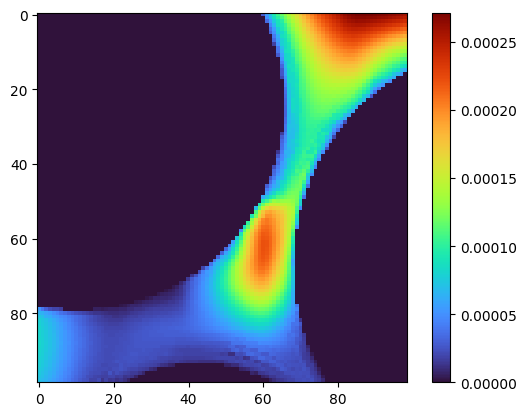

In [5]:
# compute velocity magnitude
v = np.sqrt(vx**2 + vy**2 + vz**2)

# plot a slice
slice = 20
plt.imshow(v[slice,:,:], cmap='turbo')
plt.colorbar()

## Plot orthogonal crosssections of velocity magnitude (scalars)

In [6]:
# Enable interactive plotting within a Jupyter notebook
# pythreejs is the smoothest that I have found, but is missing some PyVista functionality
# ipyvtklink has all functionality, but is much slower
# If none of the backends work for interaction, you can use 'static'
#pv.set_jupyter_backend('pythreejs')
pv.set_jupyter_backend('server')


# A function to initialize a PyVista Plotter Object
def initialize_plotter():
    
    # Initialize a PyVista Plotter Object
    plotter_obj = pv.Plotter()
    
    # Set the background color to white
    plotter_obj.set_background(color='w')
    pv.global_theme.font.color = 'black'
    
    return plotter_obj


# A function that plots orthogonal slices through the 3D image
def plot_orthogonal_slices(pv_image_obj, x_slice, y_slice, z_slice):
    ################################################################################ 
    # Input: PyVista image object (wrapped NumPy array), x, y, and z slices to plot
    # Output: PyVista plot of orthogonal slices
    ################################################################################
    
    # Initialize the PyVista plotter object
    p = initialize_plotter()
    
    # Tests to make sure input slices are within image dimensions
    assert x_slice > 0 and x_slice < pv_image_obj.dimensions[0], "X-slice value outside image dimensions"
    assert y_slice > 0 and y_slice < pv_image_obj.dimensions[1], "Y-slice value outside image dimensions"
    assert z_slice > 0 and z_slice < pv_image_obj.dimensions[2], "Z-slice value outside image dimensions"
    
    # Create three orthogonal slices through the dataset at specified X, Y, and Z values
    slices = pv_image_obj.slice_orthogonal(x=x_slice, y=y_slice, z=z_slice)
    
    # Add the slices as meshes to the PyVista plotter object
    p.add_mesh(slices)
    
    # Display the plot
    p.show()

# Wrap 3D NumPy array to PyVista data object
v_img = pv.wrap(v)    

# Get dimensions of the image
x_dim, y_dim, z_dim = v_img.dimensions

# Function call to plot the orthogonal slices.
#plot_orthogonal_slices(v_img, x_dim//2 , y_dim//2, z_dim//2)
plot_orthogonal_slices(v_img, 1 , 1, 1)

Widget(value='<iframe src="http://localhost:54009/index.html?ui=P_0x13b4fd880_0&reconnect=auto" class="pyvista…

## Plot 3D glyphs (spheres) scaled by velocity magnitude

In [11]:
# Let's place a sphere of radius that scales as velocity magnitude
n = 100 #linear size of the data above
x = np.linspace(1,n,n)
y = np.linspace(1,n,n)
z = np.linspace(1,n,n)

X, Y, Z = np.meshgrid(x,y,z)
# Get everything spaced right
s = 10      # quiver spacing

Xs = X[::s, ::s, ::s]
Ys = Y[::s, ::s, ::s]
Zs = Z[::s, ::s, ::s]
vs_norm = v[::s, ::s, ::s]/np.max(v)

# Create a structured grid
grid = pv.StructuredGrid(Xs, Ys, Zs)

# Add glyph radii to structured grid data — takes in 1D array
grid["radius"] = vs_norm.ravel()

# Initialize PyVista plotter object
p = initialize_plotter()

# Create a vtk sphere mesh to be plotted
sphere = pv.Sphere(radius=10, phi_resolution=50, theta_resolution=50)

# Use the vtk sphere mesh as glyphs, scaling each sphere by the previously calculated radii
spheres = grid.glyph(scale="radius", geom=sphere)

# Add the glyphs as a mesh to the plotter object
p.add_mesh(spheres, cmap='turbo')

# add grain surface
# Wrap 3D NumPy array to PyVista data object
v_norm = v/np.max(v);
v_norm = np.moveaxis(v_norm, 0, 2)
pv_img = pv.wrap(v_norm)
grain_isosurface = pv_img.contour(isosurfaces=[0.001])

# Add the contoured surface as a mesh to the PyVista plotter object
p.add_mesh(grain_isosurface, color=(0.7, 0.95, 1), opacity=0.2)

# Display the plot
p.show()


/Users/bchang/anaconda3/envs/agu24_workshop/lib/python3.12/site-packages/pyvista/core/filters/data_set.py:2386: UserWarning: No vector-like data to use for orient. orient will be set to False.
  warnings.warn("No vector-like data to use for orient. orient will be set to False.")


Widget(value='<iframe src="http://localhost:54009/index.html?ui=P_0x13f2f7e30_5&reconnect=auto" class="pyvista…

In [21]:
p = initialize_plotter()

# Let's place an arrow in velocity direction at selected points
n = 100 #linear size of the data above
x = np.linspace(1,n,n)
y = np.linspace(1,n,n)
z = np.linspace(1,n,n)

X, Y, Z = np.meshgrid(x,y,z)
# Get everything spaced
s = 10      # glyph spacing

Xs = X[::s, ::s, ::s]
Ys = Y[::s, ::s, ::s]
Zs = Z[::s, ::s, ::s]

# normalize velocity vectors
vx_norm = vx[::s, ::s, ::s]/np.max(v)
vy_norm = vy[::s, ::s, ::s]/np.max(v)
vz_norm = vz[::s, ::s, ::s]/np.max(v)
vs_norm = v[::s, ::s, ::s]/np.max(v)

# Create a structured grid
newgrid = pv.StructuredGrid(Xs, Ys, Zs)
newgrid["vectors"] = np.column_stack((vz_norm.ravel(), vy_norm.ravel(), vx_norm.ravel()))
newgrid["scalars"] = vs_norm.ravel()

# Make a geometric object to use as the glyph
arrow = pv.Arrow(scale=20)
arrows = newgrid.glyph(geom=arrow,orient="vectors",scale="scalars")

p.add_mesh(arrows, cmap='turbo')

# add grain surface
# Wrap 3D NumPy array to PyVista data object
v_norm = v/np.max(v);
v_norm = np.moveaxis(v_norm, 0, 2)
pv_img = pv.wrap(v_norm)
grain_isosurface = pv_img.contour(isosurfaces=[0.001])

# Add the contoured surface as a mesh to the PyVista plotter object
p.add_mesh(grain_isosurface, color=(0.7, 0.95, 1), opacity=0.2)

# Display the plot
p.show()



Widget(value='<iframe src="http://localhost:54009/index.html?ui=P_0x3a4e72f90_15&reconnect=auto" class="pyvist…

Check out the grid structures by printing the details.

In [ ]:
newgrid

In [ ]:
grid